# Embedded visualization of topics and genes

In [ ]:
import torch
import numpy as np
import pandas as pd
import scanpy as sc

te = pd.read_csv('../output/Wang/Wang_topic_embedding.csv',sep=',',index_col=0)
ge = pd.read_csv('../output/Wang/Wang_gene_embedding.csv',sep=',',index_col=0)
tg = pd.read_csv('../output/Wang/Wang_tg.csv',sep=',',index_col=0)

In [5]:
labels, embeddings = [], []
for index in range(len(ge)):
    labels.append("gene")
    embeddings.append(ge.values[index]) 

for index in range(len(te)):
    labels.append("Topic")
    embeddings.append(te.values[index])   

/mnt/rao/home/chenhg/.conda/envs/scE2TM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


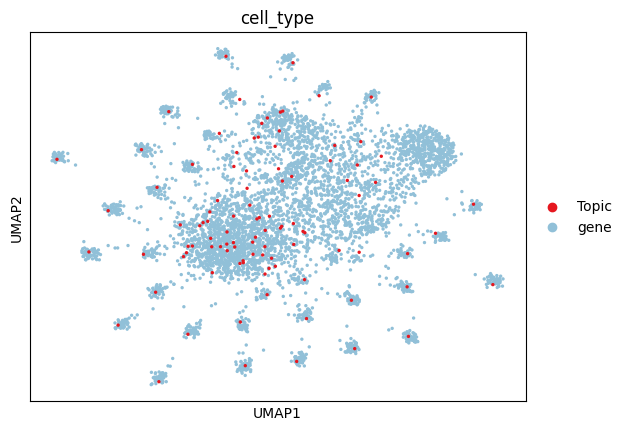

In [11]:
adata=sc.AnnData(np.array(embeddings))
adata.obs['cell_type'] = labels
sc.pp.neighbors(adata,n_neighbors=15,use_rep='X',metric='cosine')  
sc.tl.louvain(adata,resolution=1)
sc.tl.umap(adata)
adata.uns["cell_type_colors"] = np.array(["#e6171f","#91c0d8"])
sc.pl.umap(
    adata,
    color=["cell_type"],
    wspace = 0.3
)